Ce notebook va être consacré au preprocessing du dataset et l'entrainement d'un premier modèle simple pour établir une baseline.

---

# Load

In [1]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# pandas display options
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

random_state = 42
np.random.seed(random_state)
tf.random.set_seed(random_state)

base_path = 'data'
file_name = 'season.csv'
years = range(2019, 2023)

In [2]:
from f1pitpred.loading import load_from_csv

data = load_from_csv(years)

# Preprocessing

In [3]:
from f1pitpred.preprocessing import get_preprocessed_train_test_split, get_x_y_tires

train, test, encoder, train_groups, test_groups = get_preprocessed_train_test_split(
    data,
    test_size=0.4,
    return_groups=True,
    random_state=random_state,
    target='tire'
)
X_train, y_train = get_x_y_tires(train)
X_test, y_test = get_x_y_tires(test)

In [4]:
y_train.shape

(1158, 3)

In [5]:
y_train.value_counts()

NextCompound_SOFT  NextCompound_MEDIUM  NextCompound_HARD
0.0                0.0                  1.0                  524
                   1.0                  0.0                  392
1.0                0.0                  0.0                  240
0.0                0.0                  0.0                    2
Name: count, dtype: int64

# Modelisation

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix

import tensorflow.keras.backend as K

def balanced_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    return (specificity + sensitivity) / 2

def balanced_accuracy_loss(y_true, y_pred):
    tp = K.sum(y_true * y_pred)
    tn = K.sum((1 - y_true) * (1 - y_pred))
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    specificity = tn / (tn + fp + K.epsilon())
    sensitivity = tp / (tp + fn + K.epsilon())
    return 1 -(specificity + sensitivity) / 2

In [7]:
X_train = np.array(X_train).astype(np.float32)
y_train = np.array(y_train).astype(np.float32)
X_test = np.array(X_test).astype(np.float32)
y_test = np.array(y_test).astype(np.float32)

In [8]:
y_ints = [y.argmax() for y in y_train]

In [9]:

from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_ints),
    y=y_ints)

class_weights_dict = dict(enumerate(class_weights))
#class_weights_dict[0] = 2
class_weights_dict

{0: 1.5950413223140496, 1: 0.9846938775510204, 2: 0.7366412213740458}

In [10]:
from tensorflow import keras
from tensorflow.keras import layers
from keras.optimizers import Adam

def create_model(layers_param, dropout_param, learning_rate_param):
    input_dim = X_train.shape[1]
    # Create model
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for i in range(len(layers_param)):
        model.add(layers.Dense(layers_param[i], activation='relu'))
        if len(dropout_param) > i and dropout_param[i] > 0:
            model.add(layers.Dropout(dropout_param[i]))
    model.add(layers.Dense(3, activation='softmax'))

    optimizer = Adam(
        learning_rate=learning_rate_param,
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=[balanced_accuracy_loss],
        )
    
    return model

In [11]:
from keras.regularizers import l2
from keras.optimizers import Nadam
from keras.metrics import categorical_accuracy

model = keras.Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(3, activation='softmax'))

optimizer = Nadam(learning_rate=0.00005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    #metrics=[categorical_accuracy],
    )

In [12]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=1,
)

model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=300,
    callbacks=[early_stopping],
    class_weight=class_weights_dict,
    validation_data=(X_test, y_test),
    verbose=1,    
)

Epoch 1/300
37/37 [==============================] - 2s 11ms/step - loss: 12.7662 - val_loss: 8.2633
Epoch 2/300
37/37 [==============================] - 0s 6ms/step - loss: 10.6237 - val_loss: 4.9613
Epoch 3/300
37/37 [==============================] - 0s 6ms/step - loss: 9.8085 - val_loss: 4.5763
Epoch 4/300
37/37 [==============================] - 0s 6ms/step - loss: 8.8050 - val_loss: 4.1436
Epoch 5/300
37/37 [==============================] - 0s 6ms/step - loss: 8.7507 - val_loss: 5.5753
Epoch 6/300
37/37 [==============================] - 0s 6ms/step - loss: 7.2467 - val_loss: 4.3294
Epoch 7/300
37/37 [==============================] - 0s 6ms/step - loss: 7.3726 - val_loss: 3.3440
Epoch 8/300
37/37 [==============================] - 0s 6ms/step - loss: 7.2146 - val_loss: 4.2577
Epoch 9/300
37/37 [==============================] - 0s 6ms/step - loss: 6.4654 - val_loss: 3.6892
Epoch 10/300
37/37 [==============================] - 0s 8ms/step - loss: 6.0735 - val_loss: 4.1061
Epoch 

In [13]:
validation_data = load_from_csv([2023], base_path, "season.csv")

#validation_data = validation_data[validation_data['DriverNumber'] == '18']
from f1pitpred.preprocessing import preprocess_new_data
validation_df = preprocess_new_data(validation_data, encoder, target='tire', drop=True)
x_val, y_val = get_x_y_tires(validation_df)
x_val = x_val.astype(np.float32)

In [14]:
y_pred = model.predict(x_val)

8/8 [==============================] - 0s 2ms/step


In [15]:
y_pred_res = np.argmax(y_pred, axis=1)

In [16]:
y_test_res = np.argmax(y_val, axis=1)

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test_res, y_pred_res, zero_division=0))

              precision    recall  f1-score   support

           0       0.37      0.60      0.46        47
           1       0.24      0.35      0.29        49
           2       0.79      0.54      0.64       155

    accuracy                           0.51       251
   macro avg       0.47      0.49      0.46       251
weighted avg       0.61      0.51      0.54       251



In [18]:
#from sklearn.metrics import classification_report

#print(classification_report(y_test_res, y_pred_res, zero_division=0))

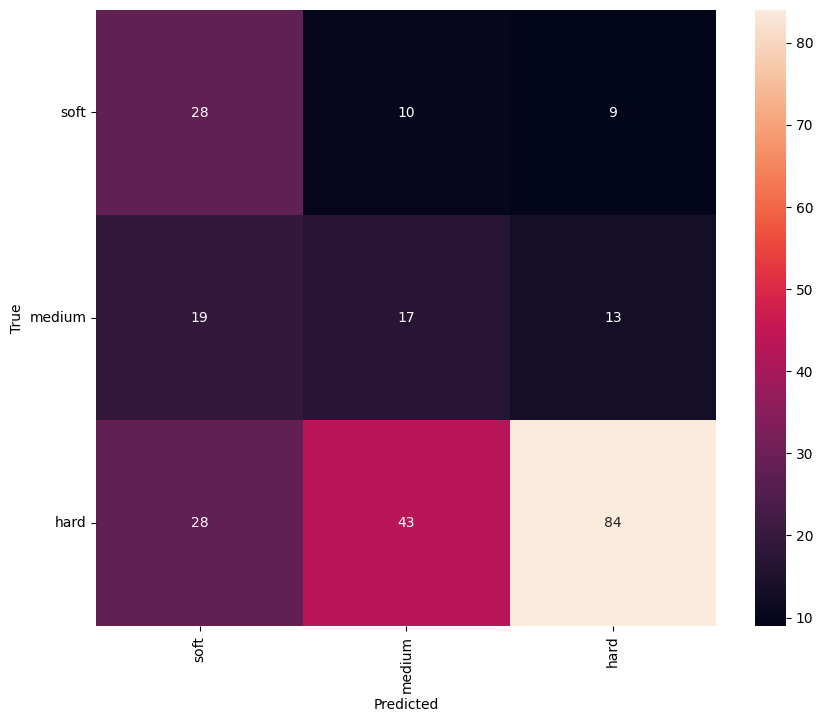

In [19]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
#print(multilabel_confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test_res, y_pred_res)
labels = ['soft', 'medium', 'hard']
class_names = labels
# Plot confusion matrix in a beautiful manner
fig = plt.figure(figsize=(10, 8))
ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax, fmt = 'g'); #annot=True to annotate cells
# labels, title and ticks
ax.set_xlabel('Predicted', fontsize=10)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize = 10)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=10)
ax.yaxis.set_ticklabels(class_names, fontsize = 10)
plt.yticks(rotation=0)
plt.savefig('confusion_matrix_tire.svg', format='svg')

In [20]:
import pickle
# Save model
models_dir = 'models/nn_tire_2'
os.makedirs(models_dir, exist_ok=True)
model.save(os.path.join(models_dir, 'model.h5'))
encoder_path = os.path.join(models_dir, 'encoder.pkl')
with open(encoder_path, 'wb') as f:
    pickle.dump(encoder, f)

C:\Users\Nelson Jeanrenaud\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [23]:
validation_data = load_from_csv([2023], base_path, "spanish_grand_prix.csv")

validation_data = validation_data[validation_data['DriverNumber'] == '1']
from f1pitpred.preprocessing import preprocess_new_data
validation_df = preprocess_new_data(validation_data, encoder, target='tire')
x, y = get_x_y_tires(validation_df)
proba = model.predict(np.array(x).astype('float32'))

2/2 [==============================] - 0s 13ms/step


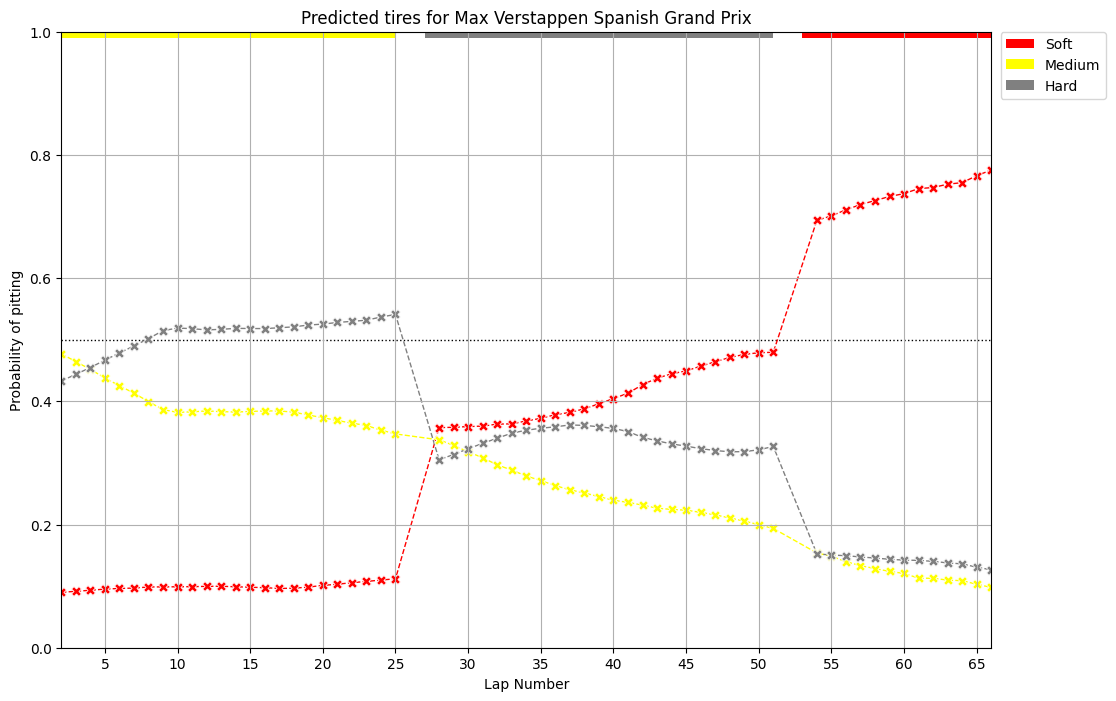

In [25]:
from f1pitpred.plotting import plot_remove_duplicate_legends

def plot_race_predictions(x, y, proba, ax, colors=['red', 'yellow', 'gray'], marker='X', labels=['Soft', 'Medium', 'Hard'], title='Predicted pitstops'):
    """
    Plot pitstop predictions for series of laps

    Parameters
    ----------
    x : pandas DataFrame
        A dataframe containing the following columns:
        - LapNumber
        - TotalLaps
    y : array-like
        The ground truth pitstop labels
    proba : array-like
        The predicted probability of pitting
    ax : matplotlib Axes
        The axes to plot on
    color : str, default 'cyan'
        The color of the plotted points
    marker : str, default 'X'
        The marker of the plotted points
    label : str, default 'Predicted pitstop'
        The label of the plotted points
    title : str, default 'Predicted pitstops'
        The title of the plot

    Returns
    -------
    ax : matplotlib Axes
        The axes with the plotted points
    """
    x['index'] = x['LapNumber']
    x = x.set_index('index')
    y.index = x.index

    ax.hlines(y=0.5, xmin=x['LapNumber'].min(), xmax=x['TotalLaps'].max(), linewidth=1, colors='black', linestyles='dotted', zorder=0)
    for i in range(len(labels)):
        sns.scatterplot(x=x['LapNumber'], y=proba[:, i], marker=marker, legend=False, ax=ax, s=50, label=labels[i], color=colors[i])
        sns.lineplot(x=x['LapNumber'], y=proba[:, i], linewidth=1, linestyle='dashed', zorder=0, ax=ax, color=colors[i])
    ax.set_xlabel('Lap Number')
    ax.set_xticks(np.arange(0, x['TotalLaps'].max(), 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability of pitting')
    ax.set_xlim(x['LapNumber'].min(), x['TotalLaps'].max())    

    ax.set_title(title)
    return plot_remove_duplicate_legends(ax, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0.)
from f1pitpred.plotting import plot_stoppages, plot_tyres

fig, ax = plt.subplots(figsize=(12, 8))
ax.grid()
plot_race_predictions(x, y, proba, ax)
plot_stoppages(x, ax)
plot_tyres(x, ax)
plt.title('Predicted tires for Max Verstappen Spanish Grand Prix')

plt.savefig('predictions_tire.svg', format='svg')